# Spectral Data Prep: Downsample TIFFs

**Purpose:** Takes a folder of spectral GeoTIFFs, resamples each one by a given factor, and writes the outputs to a subfolder. Run this once before the main notebook.

**Inputs:** Any folder of single-band GeoTIFFs (e.g. `data/raster/spectral_raw/`)  
**Outputs:** Downsampled TIFFs written to a subfolder (default: `data/raster/spectral/`)

Resampling uses bilinear interpolation (good for continuous spectral index values). The output GeoTIFFs are properly georeferenced — cell size and transform are updated automatically.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from rasterio.enums import Resampling
from rasterio.transform import Affine

In [2]:
# ── SETTINGS — edit these ──────────────────────────────────────────────────

INPUT_DIR = Path("/home/thowe/Desktop/data/clipped")  # folder containing raw TIFFs
OUTPUT_DIR = Path("data/raster/spectral")  # where downsampled TIFFs will be written

DOWNSAMPLE_FACTOR = 4  # e.g. 4 → each output pixel = 4×4 input pixels
# Try: 2 (mild), 4 (moderate), 8 (aggressive)

RESAMPLE_METHOD = Resampling.bilinear  # bilinear = smooth, good for continuous indices
# Resampling.nearest = no smoothing (for categorical)

# ── Validate ──────────────────────────────────────────────────────────────
assert INPUT_DIR.exists(), f"Input directory not found: {INPUT_DIR}"
tif_paths = sorted(INPUT_DIR.glob("*.tif"))
assert tif_paths, f"No .tif files found in {INPUT_DIR}"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Input  : {INPUT_DIR.resolve()}")
print(f"Output : {OUTPUT_DIR.resolve()}")
print(f"Files  : {len(tif_paths)}")
print(
    f"Factor : {DOWNSAMPLE_FACTOR}x  (area reduced to 1/{DOWNSAMPLE_FACTOR**2} of original)"
)

Input  : /home/thowe/Desktop/data/clipped
Output : /home/thowe/Documents/Work/python-ML-for-geologists/data/raster/spectral
Files  : 16
Factor : 4x  (area reduced to 1/16 of original)


In [ ]:
# Data preview — one file from each input directory
import geopandas as gpd

GEOCHEM_DIR  = Path('data/geochemistry')
SPECTRAL_DIR = Path('data/raster/spectral')
GEOPHYS_DIR  = Path('data/geophysics')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ── Geochemistry ───────────────────────────────────────────────────────────
geochem_files = sorted(GEOCHEM_DIR.glob('*.geojson'))
if geochem_files:
    gdf = gpd.read_file(geochem_files[0])
    gdf.plot(ax=axes[0], markersize=4, color='steelblue', alpha=0.7)
    axes[0].set_title(f'Geochemistry\n{geochem_files[0].name}\n({len(gdf)} samples)')
else:
    axes[0].text(0.5, 0.5, 'No GeoJSON found', ha='center', va='center',
                 transform=axes[0].transAxes)
    axes[0].set_title('Geochemistry')

# ── Spectral ───────────────────────────────────────────────────────────────
spec_tifs = sorted(SPECTRAL_DIR.glob('*.tif'))
if spec_tifs:
    with rasterio.open(spec_tifs[0]) as src:
        data = src.read(1).astype(float)
        if src.nodata is not None:
            data[data == src.nodata] = np.nan
        res = src.res[0]
    valid = data[np.isfinite(data)]
    vmin, vmax = np.percentile(valid, [2, 98]) if len(valid) else (0, 1)
    axes[1].imshow(data, cmap='viridis', vmin=vmin, vmax=vmax, origin='upper')
    axes[1].set_title(f'Spectral\n{spec_tifs[0].name}\n({data.shape[0]}×{data.shape[1]} px, {res:.0f} m/px)')
else:
    axes[1].text(0.5, 0.5, 'No TIFs found\n(run downsample cell first)', ha='center',
                 va='center', transform=axes[1].transAxes)
    axes[1].set_title('Spectral')
axes[1].axis('off')

# ── Geophysics ─────────────────────────────────────────────────────────────
geophys_tifs = sorted(GEOPHYS_DIR.glob('*.tif'))
if geophys_tifs:
    with rasterio.open(geophys_tifs[0]) as src:
        data = src.read(1).astype(float)
        if src.nodata is not None:
            data[data == src.nodata] = np.nan
        res = src.res[0]
    valid = data[np.isfinite(data)]
    vmin, vmax = np.percentile(valid, [2, 98]) if len(valid) else (0, 1)
    axes[2].imshow(data, cmap='plasma', vmin=vmin, vmax=vmax, origin='upper')
    axes[2].set_title(f'Geophysics\n{geophys_tifs[0].name}\n({data.shape[0]}×{data.shape[1]} px, {res:.0f} m/px)')
else:
    axes[2].text(0.5, 0.5, 'No TIFs found\nin data/geophysics/', ha='center',
                 va='center', transform=axes[2].transAxes)
    axes[2].set_title('Geophysics')
axes[2].axis('off')

axes[0].axis('off')
plt.suptitle('Input Data Preview', fontsize=12)
plt.tight_layout()
plt.show()

In [3]:
# Preview input raster sizes before committing
header = f"{'File':<40} {'Rows':>8} {'Cols':>8} {'Res (m)':>10}   {'Out rows':>9} {'Out cols':>9}"
print(header)
print("-" * len(header))
for p in tif_paths:
    with rasterio.open(p) as src:
        rows, cols = src.height, src.width
        res = src.res[0]
        out_rows = rows // DOWNSAMPLE_FACTOR
        out_cols = cols // DOWNSAMPLE_FACTOR
        print(
            f"{p.name:<40} {rows:>8} {cols:>8} {res:>10.1f}   {out_rows:>9} {out_cols:>9}"
        )

File                                         Rows     Cols    Res (m)    Out rows  Out cols
-------------------------------------------------------------------------------------------
az1000ag_clipped.tif                          545      569      500.0         136       142
azcba_clipped.tif                             545      569      500.0         136       142
azisoanom_clipped.tif                         545      569      500.0         136       142
idx_alternative_hydrothermal_alteration_clipped.tif     5505     5737       50.0        1376      1434
idx_clay_hydroxyls_clipped.tif               5505     5737       50.0        1376      1434
idx_clays_clipped.tif                        5505     5737       50.0        1376      1434
idx_ferric_iron_clipped.tif                  5505     5737       50.0        1376      1434
idx_ferric_oxide_clipped.tif                 5505     5737       50.0        1376      1434
idx_ferrous_iron_2_clipped.tif               5505     5737       50.0

In [4]:
# Downsample and write all TIFFs
written = []

for p in tif_paths:
    out_path = OUTPUT_DIR / p.name

    with rasterio.open(p) as src:
        out_height = src.height // DOWNSAMPLE_FACTOR
        out_width = src.width // DOWNSAMPLE_FACTOR

        # Read and resample in one step
        data = src.read(
            out_shape=(src.count, out_height, out_width), resampling=RESAMPLE_METHOD
        )

        # Update transform: scale the pixel size by the downsample factor
        t = src.transform
        new_transform = Affine(
            t.a * DOWNSAMPLE_FACTOR,  # pixel width
            t.b,
            t.c,
            t.d,
            t.e * DOWNSAMPLE_FACTOR,  # pixel height (negative)
            t.f,
        )

        profile = src.profile.copy()
        profile.update(
            height=out_height,
            width=out_width,
            transform=new_transform,
            compress="lzw",
            tiled=True,
            blockxsize=256,
            blockysize=256,
        )

    with rasterio.open(out_path, "w", **profile) as dst:
        dst.write(data)

    written.append(out_path)
    print(f"  Wrote: {out_path.name}  ({out_height} × {out_width})")

print(f"\nDone. {len(written)} files written to {OUTPUT_DIR}")

  Wrote: az1000ag_clipped.tif  (136 × 142)
  Wrote: azcba_clipped.tif  (136 × 142)
  Wrote: azisoanom_clipped.tif  (136 × 142)
  Wrote: idx_alternative_hydrothermal_alteration_clipped.tif  (1376 × 1434)
  Wrote: idx_clay_hydroxyls_clipped.tif  (1376 × 1434)
  Wrote: idx_clays_clipped.tif  (1376 × 1434)
  Wrote: idx_ferric_iron_clipped.tif  (1376 × 1434)
  Wrote: idx_ferric_oxide_clipped.tif  (1376 × 1434)
  Wrote: idx_ferrous_iron_2_clipped.tif  (1376 × 1434)
  Wrote: idx_ferrous_iron_clipped.tif  (1376 × 1434)
  Wrote: idx_ferrous_silicate_clipped.tif  (1376 × 1434)
  Wrote: idx_gossan_clipped.tif  (1376 × 1434)
  Wrote: idx_iron_oxide_ratio_clipped.tif  (1376 × 1434)
  Wrote: idx_laterite_clipped.tif  (1376 × 1434)
  Wrote: idx_sabins_hydrothermal_alteration_clipped.tif  (1376 × 1434)
  Wrote: idx_silica_index_clipped.tif  (1376 × 1434)

Done. 16 files written to data/raster/spectral


In [5]:
# Average output file size (post-downsample)
out_sizes = [p.stat().st_size for p in OUTPUT_DIR.glob("*.tif")]

if not out_sizes:
    print(f"No output files found in {OUTPUT_DIR} — run the downsample cell first.")
else:
    avg_bytes = sum(out_sizes) / len(out_sizes)
    if avg_bytes >= 1e9:
        print(f"Average output file size: {avg_bytes/1e9:.2f} GB")
    elif avg_bytes >= 1e6:
        print(f"Average output file size: {avg_bytes/1e6:.2f} MB")
    else:
        print(f"Average output file size: {avg_bytes/1e3:.2f} KB")

Average output file size: 6.89 MB


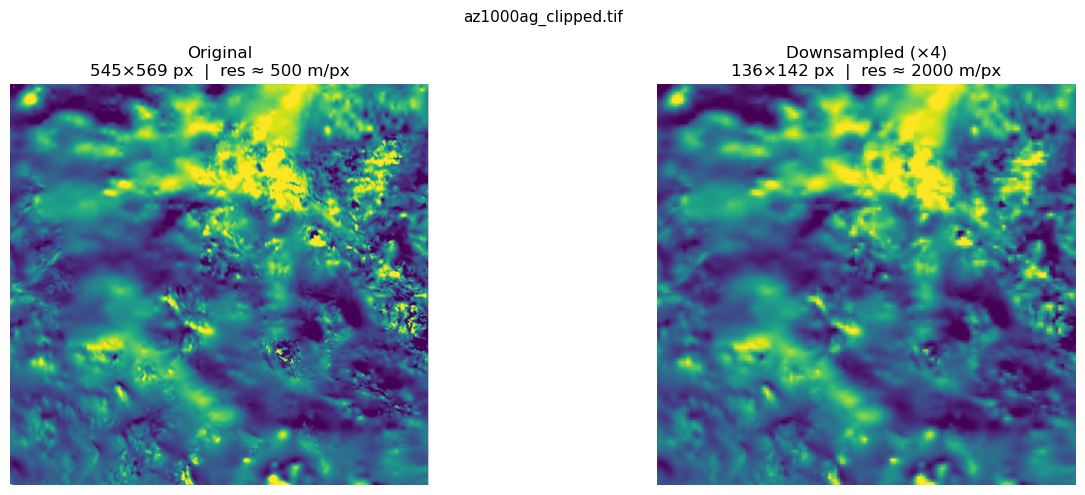

In [6]:
# Quick visual check — plot before and after for the first band
first_in = tif_paths[0]
first_out = OUTPUT_DIR / first_in.name

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, path, label in zip(
    axes, [first_in, first_out], ["Original", f"Downsampled (×{DOWNSAMPLE_FACTOR})"]
):
    with rasterio.open(path) as src:
        data = src.read(1).astype(float)
        nodata = src.nodata
        if nodata is not None:
            data[data == nodata] = np.nan
        res = src.res[0]
    valid = data[np.isfinite(data)]
    vmin, vmax = np.percentile(valid, [2, 98]) if len(valid) else (0, 1)
    ax.imshow(data, cmap="viridis", vmin=vmin, vmax=vmax, origin="upper")
    ax.set_title(
        f"{label}\n{data.shape[0]}×{data.shape[1]} px  |  res ≈ {res:.0f} m/px"
    )
    ax.axis("off")

plt.suptitle(first_in.name, fontsize=11)
plt.tight_layout()
plt.show()

In [7]:
# Summary table
print("Output files:")
for p in sorted(OUTPUT_DIR.glob("*.tif")):
    with rasterio.open(p) as src:
        mb = p.stat().st_size / 1e6
        print(f"  {p.name:<40}  {src.height:>5}×{src.width:<5}  {mb:.1f} MB")

Output files:
  az1000ag_clipped.tif                        136×142    0.1 MB
  azcba_clipped.tif                           136×142    0.1 MB
  azisoanom_clipped.tif                       136×142    0.1 MB
  idx_alternative_hydrothermal_alteration_clipped.tif   1376×1434   8.6 MB
  idx_clay_hydroxyls_clipped.tif             1376×1434   8.6 MB
  idx_clays_clipped.tif                      1376×1434   8.3 MB
  idx_ferric_iron_clipped.tif                1376×1434   8.4 MB
  idx_ferric_oxide_clipped.tif               1376×1434   8.4 MB
  idx_ferrous_iron_2_clipped.tif             1376×1434   8.4 MB
  idx_ferrous_iron_clipped.tif               1376×1434   8.5 MB
  idx_ferrous_silicate_clipped.tif           1376×1434   8.4 MB
  idx_gossan_clipped.tif                     1376×1434   8.5 MB
  idx_iron_oxide_ratio_clipped.tif           1376×1434   8.4 MB
  idx_laterite_clipped.tif                   1376×1434   8.6 MB
  idx_sabins_hydrothermal_alteration_clipped.tif   1376×1434   8.6 MB
  idx_sil